### LABORATORIO 4 CON GRAFICOS

In [71]:
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy import optimize
import cv2

In [72]:
data = 'D:\SIS-420-ACE\Laboratorios\Laboratorio_4\One_vs_All_con_Grafico\imagenes_'
x = []
y = []
num_labels = 3
mapeo_etiquetas = {'S': 0, 'R': 1, 'A': 2}

for nombre_archivo in os.listdir(data):
    if nombre_archivo.endswith(".jpg"): # Solo procesar archivos JPG
        
        # Leer la imagen
        ruta_completa = os.path.join(data, nombre_archivo)
        imagen = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE) # Leer en blanco y negro
        
        # Aplanar la imagen (de 20x20 a un vector de 400)
        imagen_plana = imagen.flatten()
        
        # Extraer la inicial del nombre del archivo
        inicial = nombre_archivo[0].upper() # Toma la primera letra en mayúscula
        
        # Guardar en nuestras listas
        x.append(imagen_plana)
        y.append(mapeo_etiquetas[inicial])

# 4. Convertir listas de Python a Arreglos de NumPy (lo que pide el modelo)
x = np.array(x)
y = np.array(y)


In [73]:
print(x)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


### FUNCION GRAFICAR

In [74]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensinal.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

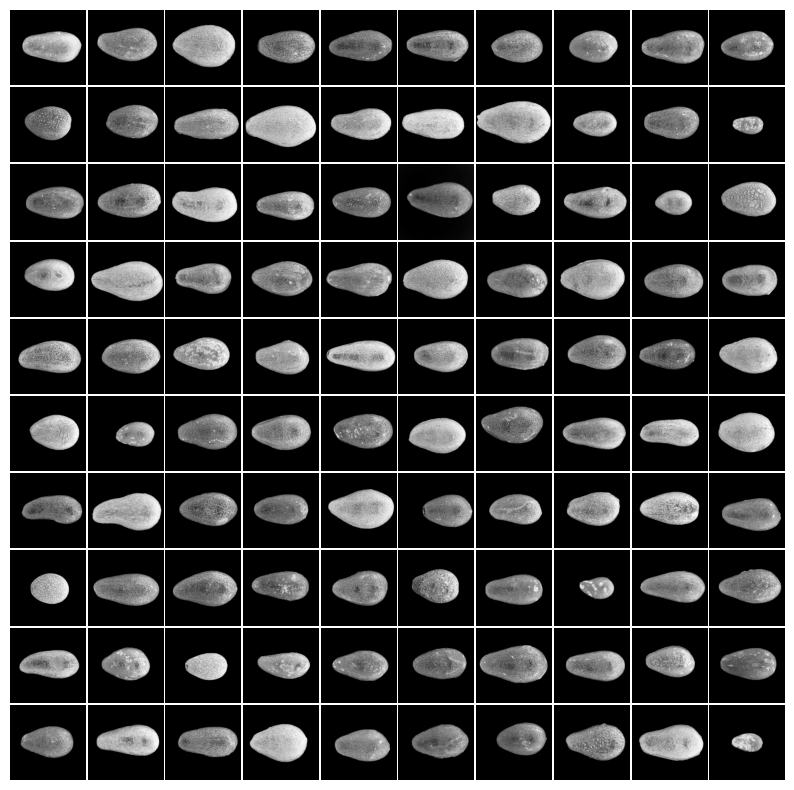

In [75]:
m = y.size
rand_indices = np.random.choice(m, 100, replace=False)
sel = x[rand_indices, :]

displayData(sel)

### FUNCION SIGMOID

In [76]:
def sigmoid(z):
    z = np.array(z)
    g = np.array(z.shape)

    

    g = 1/(1 + np.exp(-z))

    return g

### FUNCION COSTO

In [77]:
def costo(theta, x, y, lambda_):
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(x.dot(theta.T))

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # grad = (1 / m) * (h - y).dot(X)
    # grad = grad + (lambda_ / m) * temp

    grad = (1 / m) * (h - y).dot(x) + (lambda_ / m) * temp

    return J, grad

### FUNCION ONE VS ALL 

In [78]:
def oneVsAll(x, y, num_labels, lambda_):
    # algunas variables utiles
    m, n = x.shape

    # print(m, n)
    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    x = np.concatenate([np.ones((m, 1)), x], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}
        res = optimize.minimize(costo,
                                initial_theta,
                                (x, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)
        # print(res)
        all_theta[c] = res.x

    return all_theta

In [89]:
lambda_ = 0.001
# Datos de Entrenamiento (Los primeros 600)
x_train = x[:639]
y_train = y[:639]

# Datos de Prueba (Desde el 600 hasta el final)
x_test = x[639:]
y_test = y[639:]
all_theta = oneVsAll(x_train, y_train, num_labels, lambda_)
print(all_theta.shape)
print(all_theta[0])

C:\Users\ACER\AppData\Local\Temp\ipykernel_20664\4097464780.py:7: RuntimeWarning: overflow encountered in exp
  g = 1/(1 + np.exp(-z))
C:\Users\ACER\AppData\Local\Temp\ipykernel_20664\3868424.py:17: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))


(3, 90001)
[ 2.32893086e-10 -1.24833664e-06 -1.37288182e-06 ... -8.74701103e-07
 -8.74701103e-07 -8.74701103e-07]


### PREDICCION 

In [90]:
def predictOneVsAll(all_theta, x):
    m = x.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    x = np.concatenate([np.ones((m, 1)), x], axis=1)
    p = np.argmax(sigmoid(x.dot(all_theta.T)), axis = 1)

    return p

### Precision del algoritmo

In [91]:
print(x_train.shape)
pred = predictOneVsAll(all_theta, x_train)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y_train) * 100))

(639, 90000)
Precision del conjuto de entrenamiento: 77.46%


### Prediciendo

[0 0 0 0 2 0 0 2 1 0 0 0 2 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0]


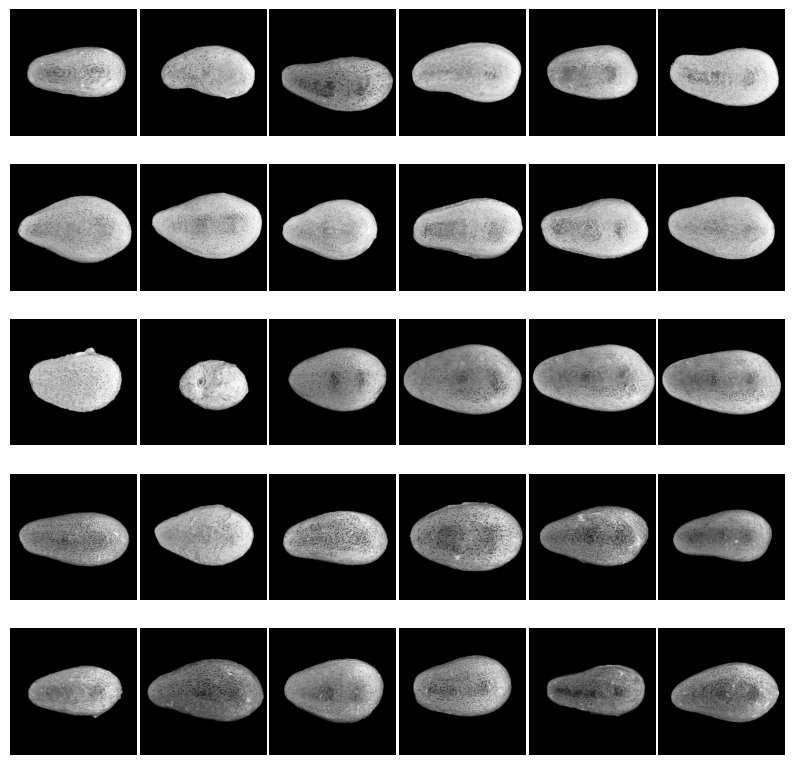

In [98]:
pred1 = predictOneVsAll(all_theta, x_test)
print(pred1)
displayData(x_test)